<div style="margin-bottom: 32px;">
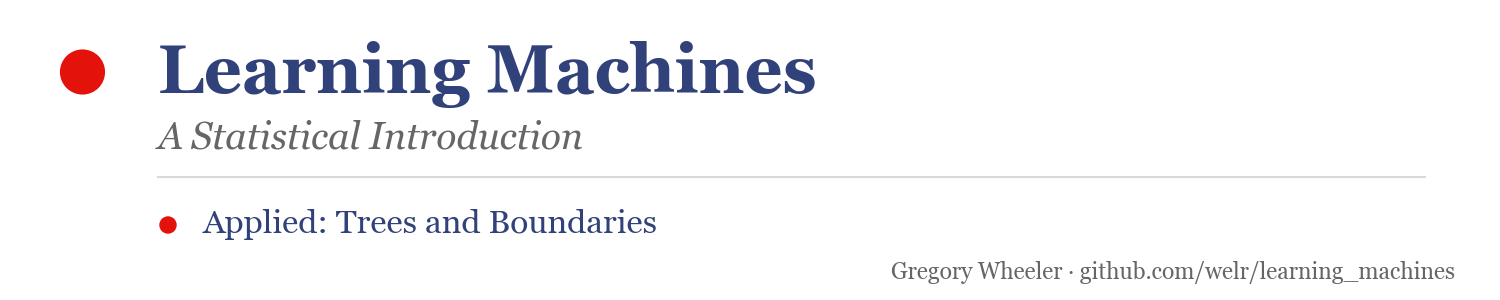
</div>


# Applied: Trees, Ensembles, and Decision Boundaries

The chapter built kernel methods, decision trees, and the two ways of combining trees---bagging (random forests) and boosting. This notebook carries those tools to a real diagnostic dataset and then, on a two-feature problem we can see, draws the decision boundary of each model class side by side.

**What computation adds**: the bagging-versus-boosting contrast stops being a slogan once you watch a single tree, a forest, and a boosted ensemble score the same held-out patients. And the inductive bias of each method---a smooth kernel similarity, an axis-aligned partition, an average over many partitions---becomes a *shape* you can point at.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
# Colab: fetch the plot-style helper if it isn't beside this notebook
import os as _os, urllib.request as _ur
if not _os.path.exists("mlone_theme.py"):
    _BASE = "https://raw.githubusercontent.com/welr/learning_machines/main/"
    for _f in ("mlone_theme.py", "mlone_style.mplstyle"):
        _ur.urlretrieve(_BASE + _f, _f)
import mlone_theme as mt

from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

plt.style.use("mlone_style.mplstyle")
mt.set_notebook_mode()                 # green companion-notebook palette
RNG = 0                                 # one seed, reused, so results are reproducible

## 1. Breast-cancer diagnosis

The Wisconsin diagnostic dataset records thirty cell-nucleus measurements for each of 569 tumors, labeled malignant or benign. We hold out a quarter of the patients, fit on the rest, and score on the held-out quarter---the honest test the chapter insists on.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RNG)
print(f"{X.shape[0]} tumors, {X.shape[1]} features; {len(X_tr)} train / {len(X_te)} test")

tree = DecisionTreeClassifier(random_state=RNG).fit(X_tr, y_tr)
print(f"single decision tree   test accuracy: {tree.score(X_te, y_te):.3f}")

569 tumors, 30 features; 426 train / 143 test
single decision tree   test accuracy: 0.902


### Bagging versus boosting

A single fully grown tree is a low-bias, high-variance learner: it fits the training tumors closely and pays for it on new ones. The chapter gave two cures. A **random forest** averages many decorrelated trees, attacking the variance directly. **Gradient boosting** adds shallow trees in sequence, each correcting the last, attacking the bias. We fit both on the same split.

In [3]:
forest = RandomForestClassifier(n_estimators=300, random_state=RNG).fit(X_tr, y_tr)
boost = GradientBoostingClassifier(random_state=RNG).fit(X_tr, y_tr)

print(f"single decision tree   test accuracy: {tree.score(X_te, y_te):.3f}")
print(f"random forest          test accuracy: {forest.score(X_te, y_te):.3f}")
print(f"gradient boosting      test accuracy: {boost.score(X_te, y_te):.3f}")
print()
print(f"forest gain over tree: {forest.score(X_te, y_te) - tree.score(X_te, y_te):+.3f}")
print(f"boost  gain over tree: {boost.score(X_te, y_te) - tree.score(X_te, y_te):+.3f}")

single decision tree   test accuracy: 0.902
random forest          test accuracy: 0.944
gradient boosting      test accuracy: 0.958

forest gain over tree: +0.042
boost  gain over tree: +0.056


Both ensembles lift accuracy well above the single tree, and the exact gaps are printed above---here gradient boosting edges out the forest, though the two land close together. The mechanism is the chapter's: a single deep tree's errors come mostly from variance, which the forest attacks directly by averaging decorrelated trees, while boosting reaches a similar place from the other side, reducing bias one shallow correction at a time. Read the two "gain" lines against the chapter's bias--variance decomposition; they are that decomposition made arithmetic.

### Feature importances and decorrelation

A random forest reports how much each feature reduced impurity across all its trees. If a few measurements dominate, that is exactly why the forest *subsamples* features at each split: left to themselves, every tree would seize the same one or two strong predictors and the trees would be near-copies. Forcing each split to choose from a random subset decorrelates them, which is what makes the average worth taking.

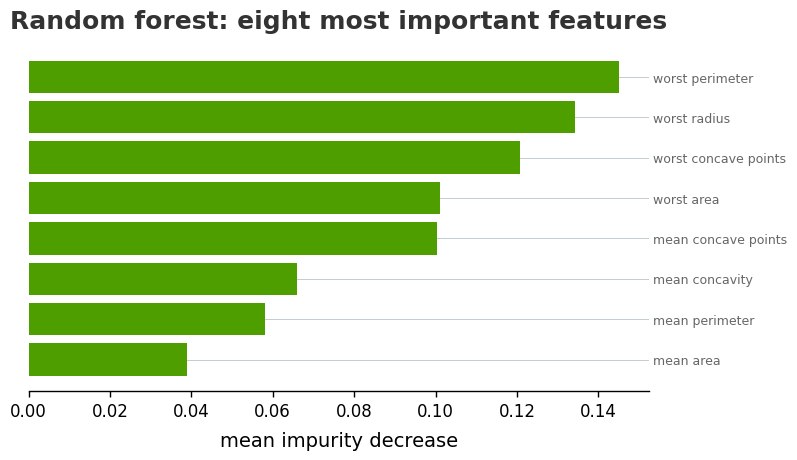

top 8 features account for 76.5% of total importance


In [4]:
importances = forest.feature_importances_
order = np.argsort(importances)[::-1][:8]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(range(len(order)), importances[order][::-1], color=mt.GREEN)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([data.feature_names[k] for k in order][::-1], fontsize=9)
ax.set_xlabel("mean impurity decrease")
ax.set_title("Random forest: eight most important features")
mt.apply_book_style(ax)
plt.show()

print(f"top 8 features account for {importances[order].sum():.1%} of total importance")

## 2. Decision boundaries across model classes

To *see* the inductive biases, we drop to two features. The `make_moons` data is two interleaving crescents---not linearly separable---with enough noise that a flexible model can overfit. We fit five classifiers on the same points and draw where each one switches its prediction.

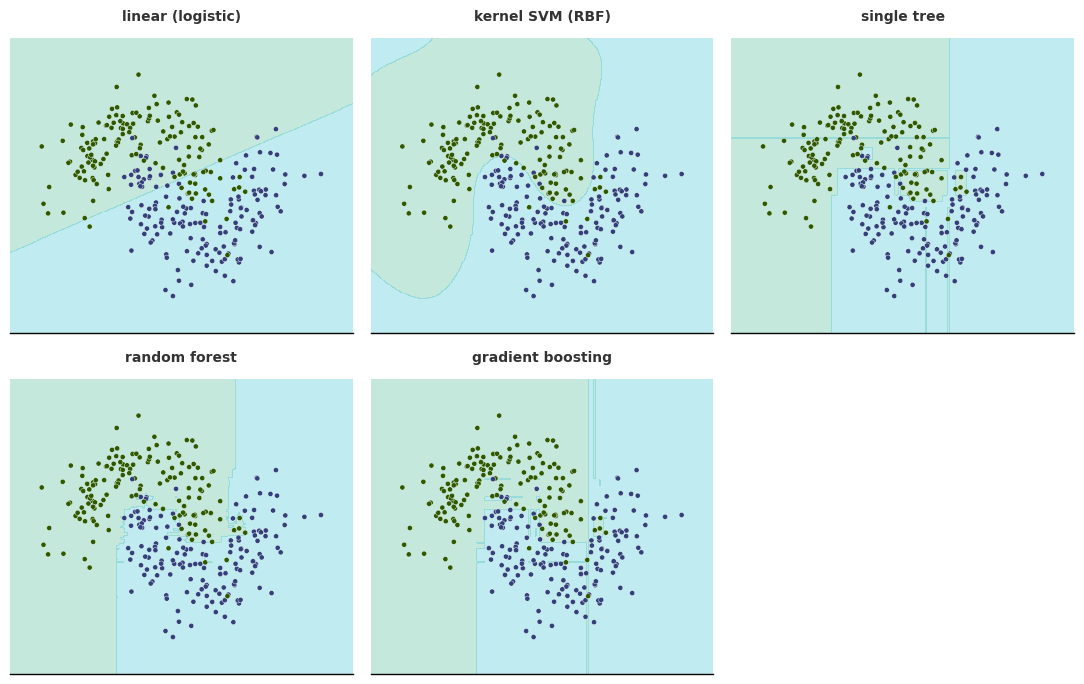

In [5]:
Xm, ym = make_moons(n_samples=300, noise=0.30, random_state=RNG)

models = [
    ("linear (logistic)", LogisticRegression()),
    ("kernel SVM (RBF)", SVC(kernel="rbf", gamma=2.0, C=1.0)),
    ("single tree", DecisionTreeClassifier(random_state=RNG)),
    ("random forest", RandomForestClassifier(n_estimators=300, random_state=RNG)),
    ("gradient boosting", GradientBoostingClassifier(random_state=RNG)),
]

bg = ListedColormap([mt.SEAFOAM, mt.CYAN])
pt = np.array([mt.FOREST, mt.FS_BLUE])

x_min, x_max = Xm[:, 0].min() - 0.5, Xm[:, 0].max() + 0.5
y_min, y_max = Xm[:, 1].min() - 0.5, Xm[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, (name, model) in zip(axes.ravel(), models):
    model.fit(Xm, ym)
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], cmap=bg, alpha=0.30)
    ax.scatter(Xm[:, 0], Xm[:, 1], c=pt[ym], s=14, edgecolors="white", linewidths=0.3)
    ax.set_title(name, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
axes.ravel()[-1].axis("off")          # five models, six panels
fig.tight_layout()
plt.show()

Read the panels against the methods.

- **Linear (logistic)** draws one straight cut. The crescents are not linearly separable, so it cannot help misclassifying a slice of each---its bias is a single hyperplane and no amount of data changes that.
- **Kernel SVM (RBF)** draws a smooth curved boundary that follows the crescents. The shape comes from a *hand-designed* similarity: nearby points are similar, and "nearby" is fixed before any data is seen.
- **Single tree** draws an axis-aligned staircase, with small islands fencing off individual noisy points. This is the high-variance learner of Part 1: it will overfit this dataset most readily, because nothing stops it from carving a box around a single mislabeled point.
- **Random forest** keeps the axis-aligned vocabulary but smooths the staircase, because it averages hundreds of trees grown on different resamples. The islands mostly dissolve.
- **Gradient boosting** is also axis-aligned, built additively; its boundary is sharper near the margin where successive trees concentrate their corrections.

The closing point of the chapter is visible here. Every one of these methods commits to a *fixed* geometry---a hyperplane, an RBF similarity, axis-aligned cuts---before seeing the data. A neural network, the next chapter's subject, instead *learns* a representation in which a problem like this becomes easy to separate, rather than fixing the shape of the boundary in advance.

**Try next.** Raise the moons' `noise` to 0.5 and refit: the single tree's islands multiply while the forest barely moves---variance reduction, on screen. Or swap in a tighter RBF (`gamma=10`) and watch the kernel SVM begin to overfit too.